In [51]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

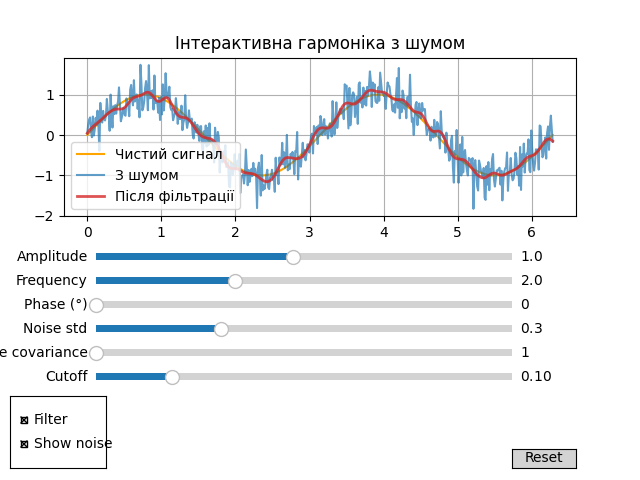

In [59]:
# --- Початкові параметри ---
amp0 = 1.0
freq0 = 2.0
phase0 = 0.0
noise_std0 = 0.3
noise_cov0 = 1  
cutoff0 = 0.1   

t = np.linspace(0, 2*np.pi, 500)

# --- Допоміжні функції ---
def harmonic(amplitude, frequency, phase):
    return amplitude * np.sin(frequency * t + phase)

def make_noise(std, cov_level):
    noise = np.random.normal(0, std, len(t))
    # якщо cov_level > 1 → робимо ковзне середнє
    if cov_level > 1:
        kernel = np.ones(int(cov_level)) / cov_level
        noise = np.convolve(noise, kernel, mode='same')
    return noise

def lowpass_filter(signal, cutoff):
    b, a = butter(4, cutoff)
    return filtfilt(b, a, signal)

# --- Початкові сигнали ---
clean = harmonic(amp0, freq0, phase0)
noise = make_noise(noise_std0, noise_cov0)
noisy = clean + noise
filtered = lowpass_filter(noisy, cutoff0)

# --- Побудова графіка ---
fig, ax = plt.subplots()
plt.subplots_adjust(left=0.1, bottom=0.55)

l_clean, = plt.plot(t, clean, lw=1.5, color='orange', label='Чистий сигнал')
l_noisy, = plt.plot(t, noisy, lw=1.5, color='tab:blue', label='З шумом', alpha=0.7)
l_filtered, = plt.plot(t, filtered, lw=2, color='tab:red', label='Після фільтрації', alpha=0.8)
plt.legend()
plt.title("Інтерактивна гармоніка з шумом")
plt.grid()

# --- Слайдери ---
axamp = plt.axes([0.15, 0.45, 0.65, 0.03])
axfreq = plt.axes([0.15, 0.40, 0.65, 0.03])
axphase = plt.axes([0.15, 0.35, 0.65, 0.03])
axnoise = plt.axes([0.15, 0.30, 0.65, 0.03])
axcov = plt.axes([0.15, 0.25, 0.65, 0.03])    
axcutoff = plt.axes([0.15, 0.20, 0.65, 0.03]) 

samp = Slider(axamp, 'Amplitude', 0.1, 2.0, valinit=amp0)
sfreq = Slider(axfreq, 'Frequency', 0.5, 5.0, valinit=freq0)
sphase = Slider(axphase, 'Phase (°)', 0.0, 360.0, valinit=np.rad2deg(phase0))
snoise = Slider(axnoise, 'Noise std', 0.0, 1.0, valinit=noise_std0)
scov = Slider(axcov, 'Noise covariance', 1, 30, valinit=noise_cov0, valstep=1)
scutoff = Slider(axcutoff, 'Cutoff', 0.01, 0.5, valinit=cutoff0)

# --- Кнопка Reset ---
resetax = plt.axes([0.8, 0.025, 0.1, 0.04])
button = Button(resetax, 'Reset', color='lightgray')

# --- Чекбокси ---
rax = plt.axes([0.015, 0.025, 0.15, 0.15])
check = CheckButtons(rax, ['Filter', 'Show noise'], [True, True])

# --- Глобальні змінні ---
current_clean = clean.copy()
current_noise = noise.copy()

# --- Функція оновлення ---
def update(val):
    global current_clean, current_noise

    phase_rad = np.deg2rad(sphase.val)

    # Якщо змінюється Noise std або Covariance → оновлюємо шум
    if val in ['noise', 'cov'] or snoise.val != update.last_std or scov.val != update.last_cov:
        current_noise = make_noise(snoise.val, scov.val)
        update.last_std = snoise.val
        update.last_cov = scov.val

    # Якщо змінюється гармоніка → оновлюємо тільки clean
    current_clean = harmonic(samp.val, sfreq.val, phase_rad)

    # Комбінуємо
    noisy_new = current_clean + current_noise

    # Показуємо/ховаємо шум
    if check.get_status()[1]:
        l_noisy.set_ydata(noisy_new)
        l_noisy.set_visible(True)
    else:
        l_noisy.set_visible(False)

    # Фільтрація
    if check.get_status()[0]:
        filt = lowpass_filter(noisy_new, scutoff.val)
        l_filtered.set_ydata(filt)
        l_filtered.set_visible(True)
    else:
        l_filtered.set_visible(False)

    l_clean.set_ydata(current_clean)
    fig.canvas.draw_idle()

# --- Зберігаємо останні значення шуму ---
update.last_std = snoise.val
update.last_cov = scov.val

# --- Reset ---
def reset(event):
    global current_clean, current_noise
    samp.reset(); sfreq.reset(); sphase.reset()
    snoise.reset(); scov.reset(); scutoff.reset()
    current_clean = harmonic(amp0, freq0, phase0)
    current_noise = make_noise(noise_std0, noise_cov0)
    update(None)

def toggle_checkbox(label):
    update(None)

# --- Прив’язка подій ---
samp.on_changed(update)
sfreq.on_changed(update)
sphase.on_changed(update)
snoise.on_changed(lambda val: update('noise'))
scov.on_changed(lambda val: update('cov'))
scutoff.on_changed(update)
button.on_clicked(reset)
check.on_clicked(toggle_checkbox)

plt.show()
